# A1 — Horizon 2031 : cartes et graphes

Ce notebook **montre** les résultats de l’annexe A1. Il ne produit aucun chiffre de l’annexe : ces chiffres viennent des CSV écrits par `scripts/horizon_A1.py` (`data/analysis/A1_horizon/`, R-19).

**Ce qu’on regarde**, aux 5 paliers (2022 passé, 2026 actuel, 2027, 2029, 2031) :
- la population par préfecture et par zone, avec sa fourchette (a)–(b) ;
- les besoins : auto-écoles à ouvrir, km à remettre en état, ruraux loin d’une route revêtue, sans action et avec action ;
- au national : permis moto, accidents, blessés et tués, avec les deux références sans action, la cible de la Décennie et le plafond du casque ;
- la vérification avec la grille WorldPop : accès rural et emplacements des auto-écoles.

**Limite commune à toutes les vues** : valeurs C, des estimations et non des prévisions. Auto-écoles de la collecte 2021-2022, activité non vérifiée ; état du réseau relevé en 2020 ; tués déclarés, sous l’estimation de l’OMS (SE-03). Les accidents et les permis ne sont publiés qu’au niveau national : aucune carte ne les montre.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display
from style_06 import *
appliquer_style()
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

A1 = RACINE / "data" / "analysis" / "A1_horizon"
h = pd.read_csv(A1 / "horizon_A1.csv")
pop = pd.read_csv(A1 / "population_A1.csv")
nat = pd.read_csv(A1 / "national_A1.csv")
acc = pd.read_csv(A1 / "acces_A1.csv")
emp = pd.read_csv(A1 / "emplacements_A1.csv")
sites = pd.read_csv(A1 / "sites_A1.csv")
geo = gpd.read_file(TRAITE / "geo" / "prefectures.geojson").to_crs(UTM31N)[["Préfecture", "Zone", "geometry"]]
zones_geo = geo.dissolve("Zone").reset_index()

PALIERS = {2022: "2022 · passé", 2026: "2026 · actuel", 2027: "2027 · +1 an", 2029: "2029 · +3 ans", 2031: "2031 · +5 ans"}
BLEUS = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # rampe de la maquette : un palier par pas, du passé à +5 ans
LIMITE = "Valeurs C (estimations, pas des prévisions). Population : recensement 2022, projections de l’INSEED ; variante (b), fourchette (a)–(b)."

def fond(ax, titre):
    zones_geo.boundary.plot(ax=ax, color=ENCRE_2, linewidth=0.7)
    nettoyer(ax); ax.set_aspect("equal"); ax.set_title(titre, fontsize=10)

def carte(ax, valeurs, classes, titre, hachures=None):
    """Choroplèthe en classes fixes : `classes` = liste de (libellé, couleur, fonction de test)."""
    g = geo.assign(v=geo["Préfecture"].map(valeurs))
    def coul(v):
        if pd.isna(v):
            return NON_DEFINI
        for _, c, test in classes:
            if test(v):
                return c
    g.plot(ax=ax, color=[coul(v) for v in g["v"]], edgecolor=SURFACE, linewidth=0.6)
    if hachures is not None:
        g[g["v"].map(hachures)].plot(ax=ax, facecolor="none", edgecolor=ENCRE_2, hatch="////", linewidth=0)
    fond(ax, titre)

def legende(fig, classes, titre, extra=()):
    poignees = [Patch(facecolor=c, label=l) for l, c, _ in classes] + list(extra)
    fig.legend(handles=poignees, loc="upper center", ncol=len(poignees), fontsize=8, title=titre, title_fontsize=8,
               bbox_to_anchor=(0.5, 0.04))

def pied_bas(fig, texte):
    """Pied sous une légende placée en bas de la figure."""
    fig.text(0.01, -0.09, texte, fontsize=8, color=MUET)

def prefectures(levier, perimetre=None):
    d = h[(h["Maille"] == "Préfecture") & (h["Levier"] == levier)]
    return d if perimetre is None else d[d["Périmètre"] == perimetre]

## 1. Population projetée

La population de chaque préfecture suit la variante (b) : la croissance de sa région entre les recensements de 2010 et de 2022, ramenée au total de l’INSEED. Les classes de densité sont les quartiles de 2022, gardés en 2031.

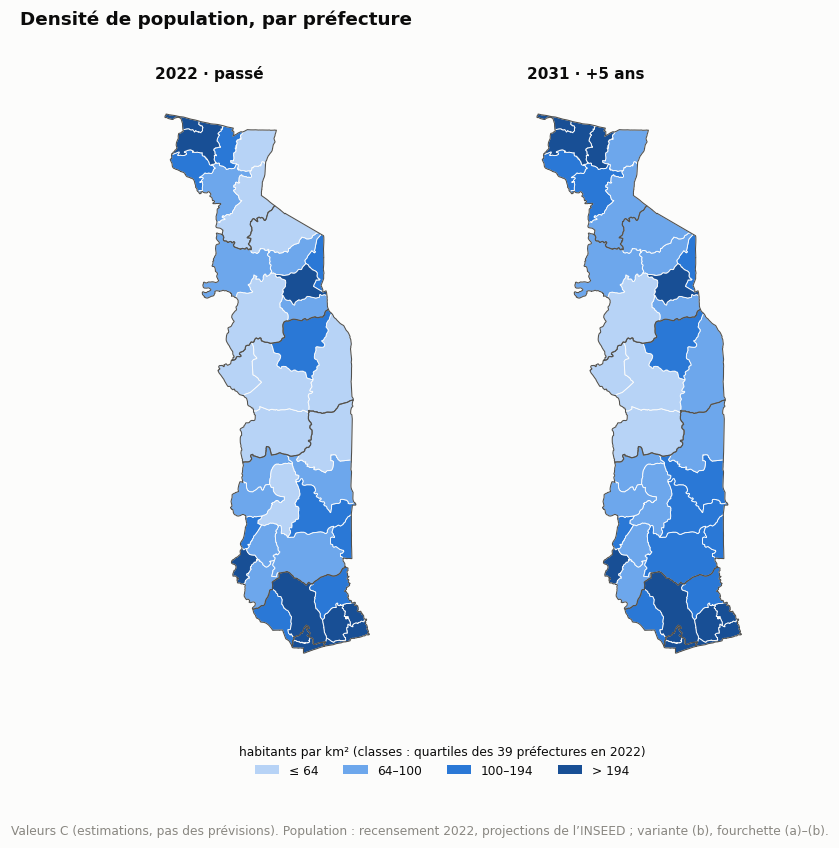

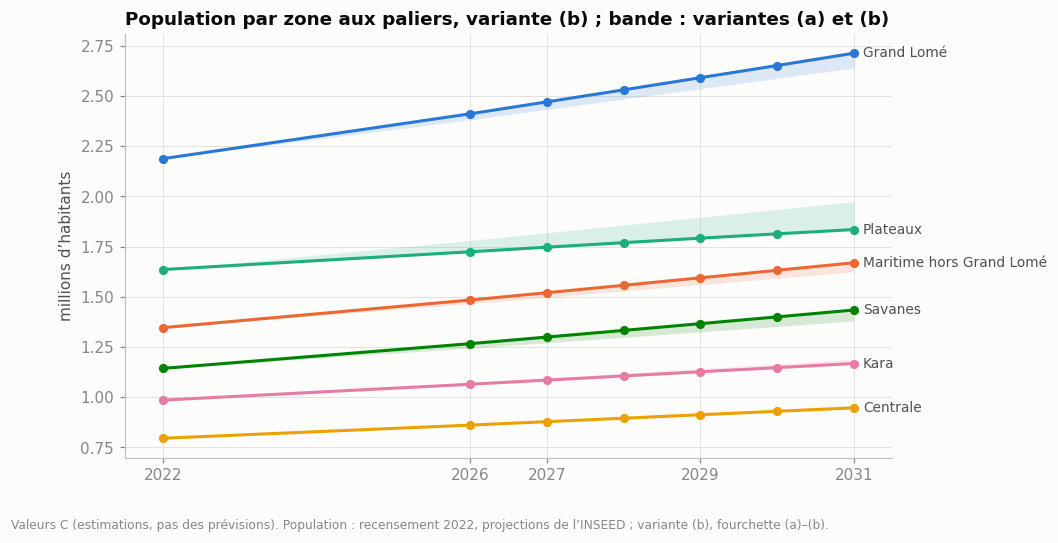

Année,2022,2026,2027,2028,2029,2030,2031
Zone,,,,,,,
Grand Lomé,2188376,2411648,2471136,2530912,2591526,2652152,2713339
Maritime hors Grand Lomé,1346615,1484005,1520610,1557395,1594693,1631999,1669651
Plateaux,1635946,1724349,1747324,1769782,1792109,1813734,1835036
Centrale,795529,860913,878154,895321,912611,929729,946870
Kara,985512,1064423,1085207,1105880,1126685,1147255,1167833
Savanes,1143520,1266660,1299568,1332710,1366375,1400133,1434271


In [2]:
p22 = pop[pop["Année"] == 2022].set_index("Préfecture")["Densité (hab./km²)"]
q = p22.quantile([0.25, 0.5, 0.75]).to_numpy()
CL_DENS = [(f"≤ {q[0]:.0f}", SEQUENTIEL[0], lambda v: v <= q[0]), (f"{q[0]:.0f}–{q[1]:.0f}", SEQUENTIEL[1], lambda v: q[0] < v <= q[1]),
           (f"{q[1]:.0f}–{q[2]:.0f}", SEQUENTIEL[2], lambda v: q[1] < v <= q[2]), (f"> {q[2]:.0f}", SEQUENTIEL[3], lambda v: v > q[2])]
fig, axes = plt.subplots(1, 2, figsize=(8, 7))
for ax, an in zip(axes, (2022, 2031)):
    carte(ax, pop[pop["Année"] == an].set_index("Préfecture")["Densité (hab./km²)"], CL_DENS, PALIERS[an])
legende(fig, CL_DENS, "habitants par km² (classes : quartiles des 39 préfectures en 2022)")
fig.suptitle("Densité de population, par préfecture", x=0.02, ha="left", fontweight="bold")
pied_bas(fig, LIMITE)
plt.show()

z = pop.groupby(["Zone", "Année"])[["Population", "Borne basse", "Borne haute", "Population (a)", "Population (b)"]].sum().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
fin = {}
for couleur, zone in zip(SERIES, ZONES):
    s = z[z["Zone"] == zone].set_index("Année")
    ax.plot(s.index, s["Population"] / 1e6, color=couleur, marker="o", markersize=5)
    ax.fill_between(s.index, s["Borne basse"] / 1e6, s["Borne haute"] / 1e6, color=couleur, alpha=0.15, linewidth=0)
    fin[zone] = s["Population"].iloc[-1] / 1e6
ax.set_xlim(2021.5, 2031.5); axe_annees(ax)
ax.set_xticks(list(PALIERS)); ax.set_ylabel("millions d’habitants")
etiquettes_fin(ax, 2031, fin, ecart=0.05)
ax.set_title("Population par zone aux paliers, variante (b) ; bande : variantes (a) et (b)")
pied(fig, LIMITE)
plt.show()
display(z.pivot(index="Zone", columns="Année", values="Population").loc[ZONES].astype(int))

## 2. Auto-écoles : le taux baisse sans action, et le manque grandit

Haut : auto-écoles comptées pour 100 000 habitants si rien ne change (les auto-écoles de 2021-2022 rapportées à la population du palier). Bas : auto-écoles à ouvrir pour atteindre 1,065 pour 100 000 habitants. Les classes sont fixes : elles se comparent d’un palier à l’autre.

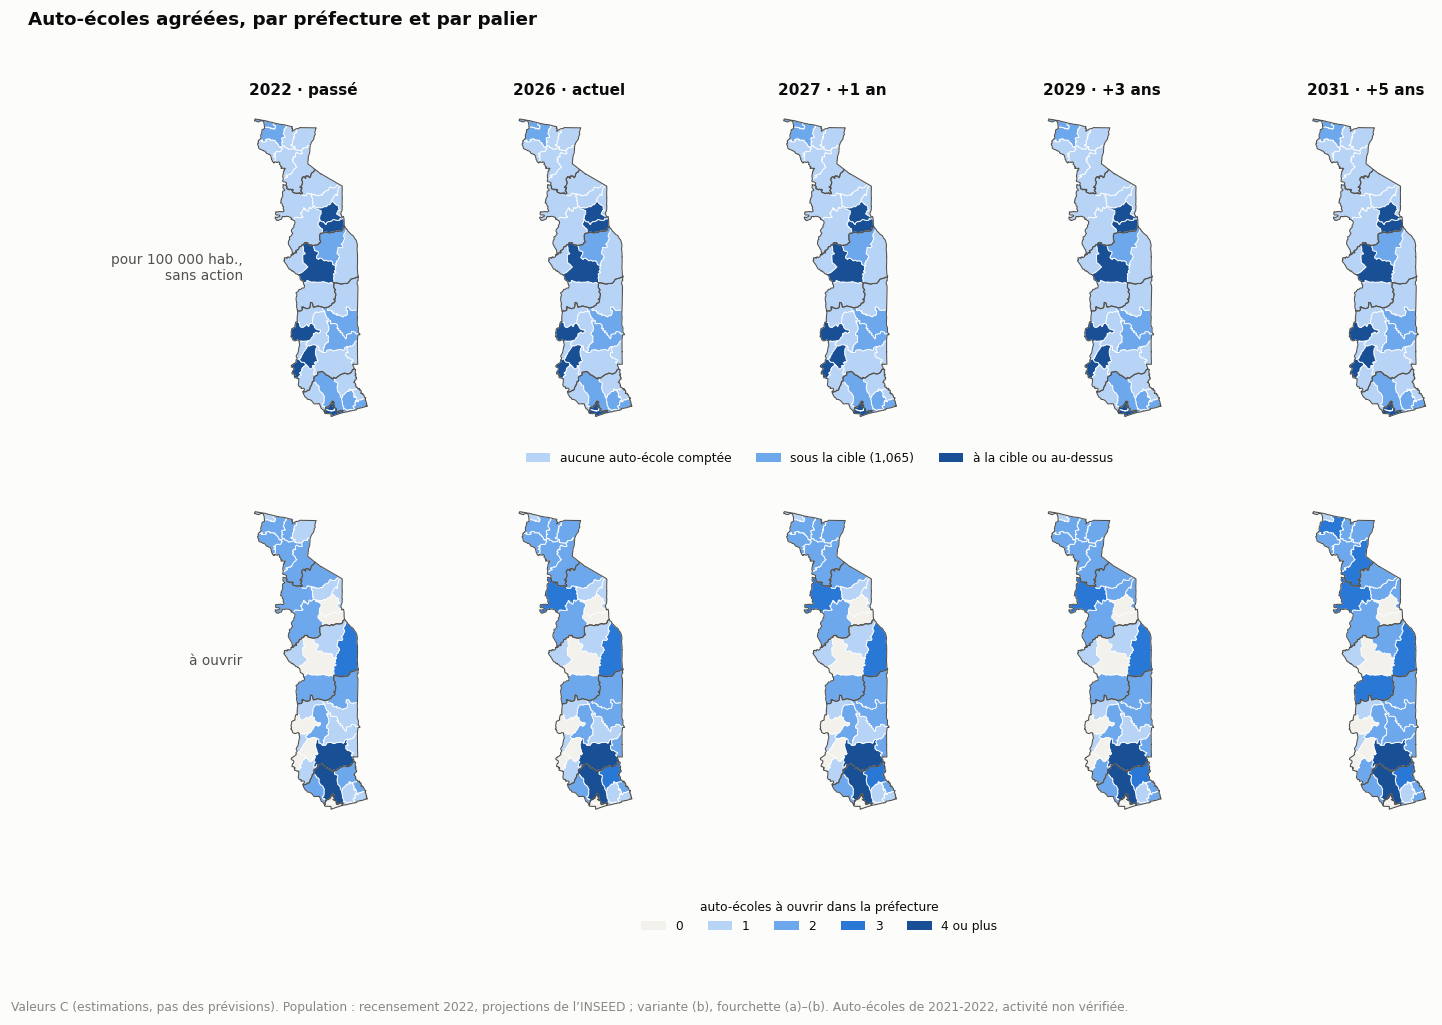

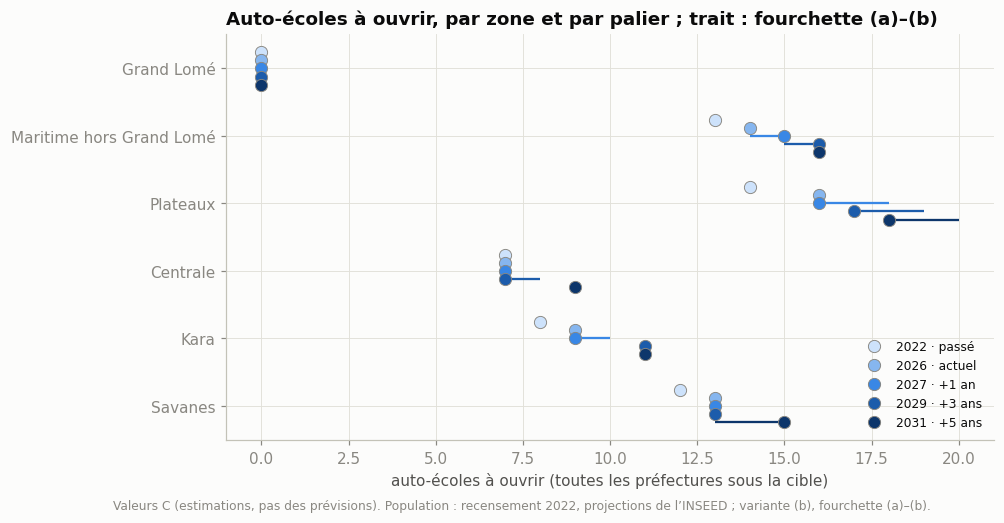

Année,2022,2026,2027,2029,2031
Territoire,,,,,
Grand Lomé,0,0,0,0,0
Maritime hors Grand Lomé,13,14,15,16,16
Plateaux,14,16,16,17,18
Centrale,7,7,7,7,9
Kara,8,9,9,11,11
Savanes,12,13,13,13,15


In [3]:
ae = prefectures("Auto-écoles")
CL_TAUX = [("aucune auto-école comptée", SEQUENTIEL[0], lambda v: v == 0), ("sous la cible (1,065)", SEQUENTIEL[1], lambda v: 0 < v < 1.065),
           ("à la cible ou au-dessus", SEQUENTIEL[3], lambda v: v >= 1.065)]
CL_OUV = [("0", "#f2f1ec", lambda v: v == 0), ("1", SEQUENTIEL[0], lambda v: v == 1), ("2", SEQUENTIEL[1], lambda v: v == 2),
          ("3", SEQUENTIEL[2], lambda v: v == 3), ("4 ou plus", SEQUENTIEL[3], lambda v: v >= 4)]
fig, axes = plt.subplots(2, 5, figsize=(15, 8.5))
for j, an in enumerate(PALIERS):
    d = ae[ae["Année"] == an].set_index("Territoire")
    carte(axes[0, j], d["Sans action"], CL_TAUX, PALIERS[an])
    carte(axes[1, j], d["Valeur"], CL_OUV, "")
axes[0, 0].annotate("pour 100 000 hab.,\nsans action", (-0.05, 0.5), xycoords="axes fraction", ha="right", va="center", fontsize=9, color=ENCRE_2)
axes[1, 0].annotate("à ouvrir", (-0.05, 0.5), xycoords="axes fraction", ha="right", va="center", fontsize=9, color=ENCRE_2)
fig.legend(handles=[Patch(facecolor=c, label=l) for l, c, _ in CL_TAUX], loc="upper center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, 0.52))
legende(fig, CL_OUV, "auto-écoles à ouvrir dans la préfecture")
fig.suptitle("Auto-écoles agréées, par préfecture et par palier", x=0.02, ha="left", fontweight="bold")
pied_bas(fig, LIMITE + " Auto-écoles de 2021-2022, activité non vérifiée.")
plt.show()

zr = h[(h["Maille"] == "Zone") & (h["Levier"] == "Auto-écoles") & (h["Périmètre"] == "Toutes les préfectures")]
fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(ZONES))
for k, an in enumerate(PALIERS):
    s = zr[zr["Année"] == an].set_index("Territoire").loc[ZONES]
    ax.errorbar(s["Valeur"], y + (k - 2) * 0.12, xerr=[s["Valeur"] - s["Borne basse"], s["Borne haute"] - s["Valeur"]],
                fmt="o", color=BLEUS[k], markersize=8, markeredgecolor=MUET, markeredgewidth=0.6, elinewidth=1.5, label=PALIERS[an])
ax.set_yticks(y, ZONES); ax.invert_yaxis(); ax.set_xlabel("auto-écoles à ouvrir (toutes les préfectures sous la cible)")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Auto-écoles à ouvrir, par zone et par palier ; trait : fourchette (a)–(b)")
pied(fig, LIMITE)
plt.show()
display(zr.pivot(index="Territoire", columns="Année", values="Valeur").loc[ZONES].astype(int))

## 3. Routes : remise en état et accès rural

La remise en état ne dépend pas de la population : un seul panneau sans action, un avec action (les 13 préfectures du levier ramenées à 14,35 %). L’accès rural se compte en habitants : les ruraux à plus de 2 km d’une route nationale revêtue augmentent avec la population, sans cible (10 §4.6).

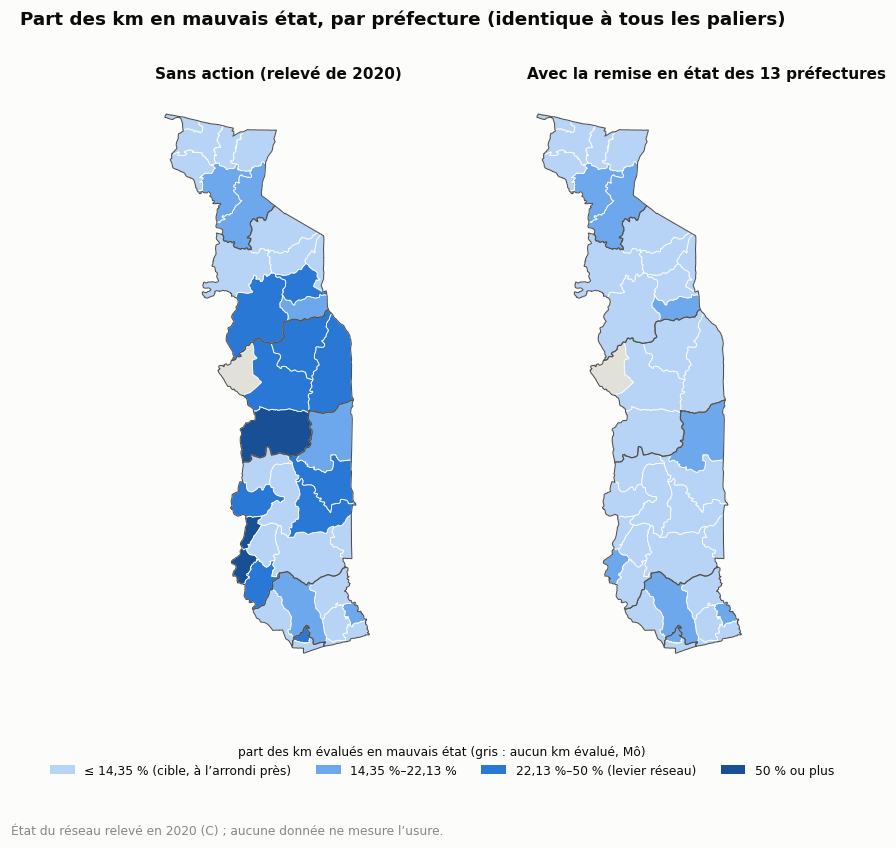

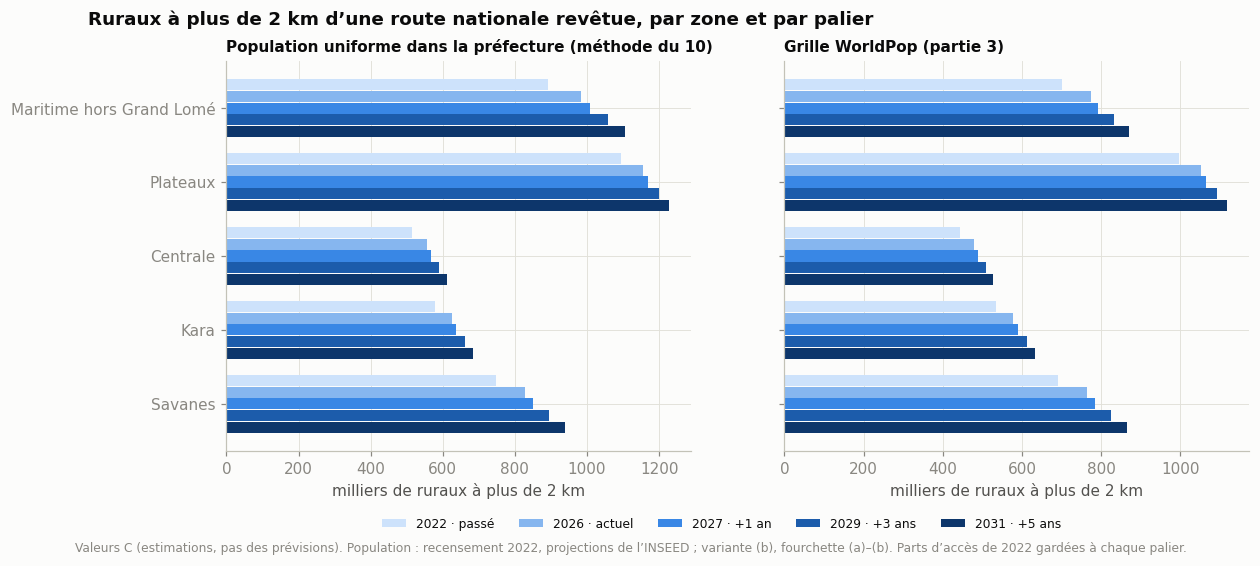

Année,2022,2026,2027,2029,2031
Territoire,,,,,
Maritime hors Grand Lomé,892565,983630,1007893,1056997,1106680
Plateaux,1094908,1154073,1169451,1199425,1228156
Centrale,514276,556545,567689,589964,612111
Kara,578139,624432,636624,660956,685096
Savanes,748163,828730,850260,893970,938391


In [4]:
re_ = prefectures("Remise en état")
re22 = re_[re_["Année"] == 2022].set_index("Territoire")
avec = re22["Sans action"].where(re22["Périmètre"] != "Levier du 08", re22["Avec action"])
CL_ETAT = [("≤ 14,35 % (cible, à l’arrondi près)", SEQUENTIEL[0], lambda v: v < 14.4), ("14,35 %–22,13 %", SEQUENTIEL[1], lambda v: 14.4 <= v < 22.13),
           ("22,13 %–50 % (levier réseau)", SEQUENTIEL[2], lambda v: 22.13 <= v < 50), ("50 % ou plus", SEQUENTIEL[3], lambda v: v >= 50)]
fig, axes = plt.subplots(1, 2, figsize=(8, 7))
carte(axes[0], re22["Sans action"], CL_ETAT, "Sans action (relevé de 2020)")
carte(axes[1], avec, CL_ETAT, "Avec la remise en état des 13 préfectures")
legende(fig, CL_ETAT, "part des km évalués en mauvais état (gris : aucun km évalué, Mô)")
fig.suptitle("Part des km en mauvais état, par préfecture (identique à tous les paliers)", x=0.02, ha="left", fontweight="bold")
pied_bas(fig, "État du réseau relevé en 2020 (C) ; aucune donnée ne mesure l’usure.")
plt.show()

ar = h[(h["Maille"] == "Zone") & (h["Levier"] == "Accès rural")]
ag = acc[acc["Maille"] == "Zone"]
rur = [zz for zz in ZONES if zz != "Grand Lomé"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, (titre, col, src) in zip(axes, (("Population uniforme dans la préfecture (méthode du 10)", "Valeur", ar),
                                         ("Grille WorldPop (partie 3)", "Ruraux à plus de 2 km, grille", ag))):
    y = np.arange(len(rur))
    for k, an in enumerate(PALIERS):
        s = src[src["Année"] == an].set_index("Territoire").loc[rur]
        ax.barh(y + (k - 2) * 0.16, s[col] / 1e3, height=0.15, color=BLEUS[k], label=PALIERS[an])
    ax.set_yticks(y, rur); ax.set_title(titre, fontsize=10); ax.set_xlabel("milliers de ruraux à plus de 2 km")
axes[0].invert_yaxis()  # axe partagé : une seule inversion
axes[1].tick_params(labelleft=False)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=5, fontsize=8, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Ruraux à plus de 2 km d’une route nationale revêtue, par zone et par palier", x=0.02, ha="left", fontweight="bold")
pied_bas(fig, LIMITE + " Parts d’accès de 2022 gardées à chaque palier.")
plt.show()
display(ar.pivot(index="Territoire", columns="Année", values="Valeur").loc[rur].astype(int))

## 4. Vérification avec la grille WorldPop : l’accès rural par zone

Le 10 (§4.6) supposait la population rurale répartie uniformément dans chaque préfecture. Avec la grille, les ruraux sont là où la grille les place. Critère fixé avant le calcul (A1 §6) : la conclusion du 10 est confirmée si les mêmes zones restent sous la médiane des zones.

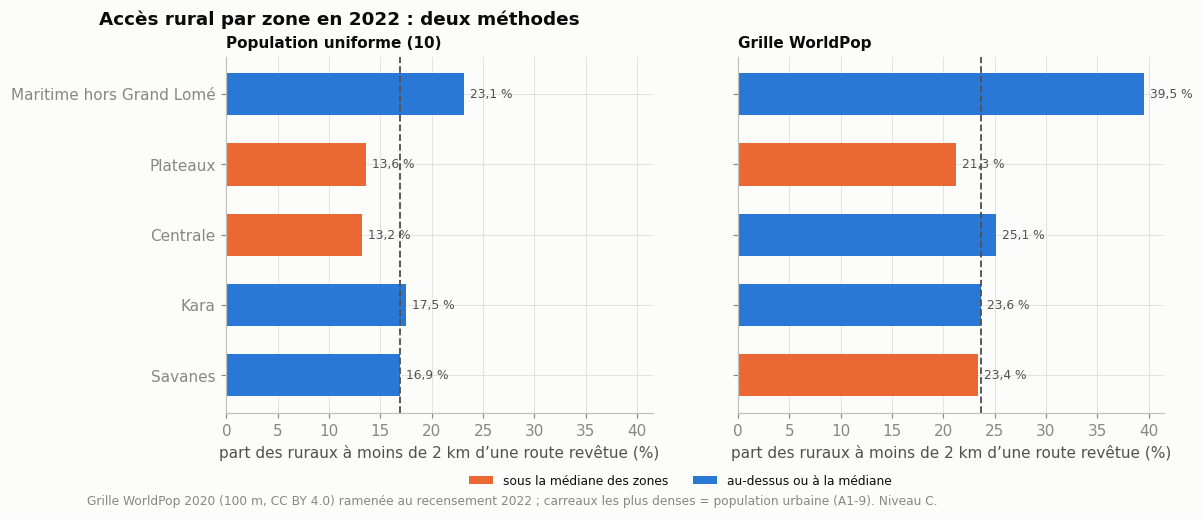

,Maille,Territoire,Note
230,Médiane des zones,uniforme,"zones sous la médiane : Centrale, Plateaux"
231,Médiane des zones,grille,"zones sous la médiane : Plateaux, Savanes"
232,Conclusion du 10 §4.6,corrigée,"10 : Centrale, Plateaux ; grille : Plateaux, Savanes ; critère fixé avant le calcul (A1 §6)"


In [5]:
z22 = acc[(acc["Maille"] == "Zone") & (acc["Année"] == 2022)].set_index("Territoire").loc[rur]
med = acc[acc["Maille"] == "Médiane des zones"].set_index("Territoire")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for ax, (k, col) in zip(axes, (("uniforme", "Accès rural, uniforme (%)"), ("grille", "Accès rural, grille (%)"))):
    m = med.at[k, f"Accès rural, {k} (%)"]
    couleurs = [SERIES[1] if v < m else SERIES[0] for v in z22[col]]
    ax.barh(rur, z22[col], color=couleurs, height=0.6)
    ax.axvline(m, color=ENCRE_2, linestyle="--", linewidth=1.2)
    ax.annotate(f"médiane des zones : {m:.2f} %".replace(".", ","), (m, -0.6), xytext=(4, 0), textcoords="offset points", fontsize=8, color=ENCRE_2)
    for i, v in enumerate(z22[col]):
        ax.annotate(f"{v:.1f} %".replace(".", ","), (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8, color=ENCRE_2)
    ax.set_title("Population uniforme (10)" if k == "uniforme" else "Grille WorldPop", fontsize=10)
    ax.set_xlabel("part des ruraux à moins de 2 km d’une route revêtue (%)")
axes[0].invert_yaxis(); axes[1].tick_params(labelleft=False)
fig.legend(handles=[Patch(facecolor=SERIES[1], label="sous la médiane des zones"), Patch(facecolor=SERIES[0], label="au-dessus ou à la médiane")],
           loc="upper center", ncol=2, fontsize=8, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Accès rural par zone en 2022 : deux méthodes", x=0.02, ha="left", fontweight="bold")
pied_bas(fig, "Grille WorldPop 2020 (100 m, CC BY 4.0) ramenée au recensement 2022 ; carreaux les plus denses = population urbaine (A1-9). Niveau C.")
plt.show()
display(acc[acc["Maille"].isin(["Médiane des zones", "Conclusion du 10 §4.6"])][["Maille", "Territoire", "Note"]])

## 5. Emplacements des auto-écoles : sites optimisés et site indicatif

Pour les 23 préfectures du levier formation, autant de sites que d’auto-écoles à ouvrir en 2029, choisis pour couvrir le plus d’habitants à moins de 10 km. Le site indicatif du 10 est le point de départ de O4-08 (chef-lieu ou point d’étiquette) : y ouvrir toutes les auto-écoles ne couvre que ses environs.

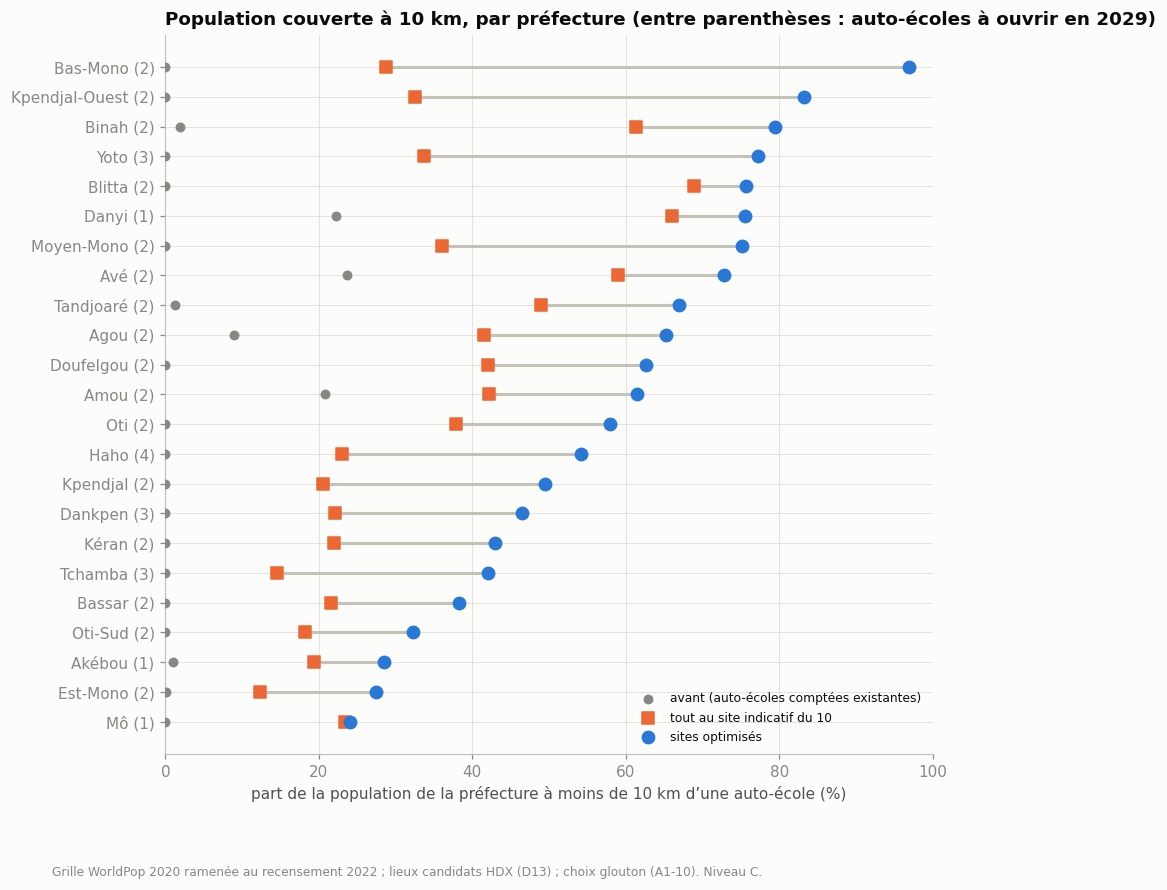

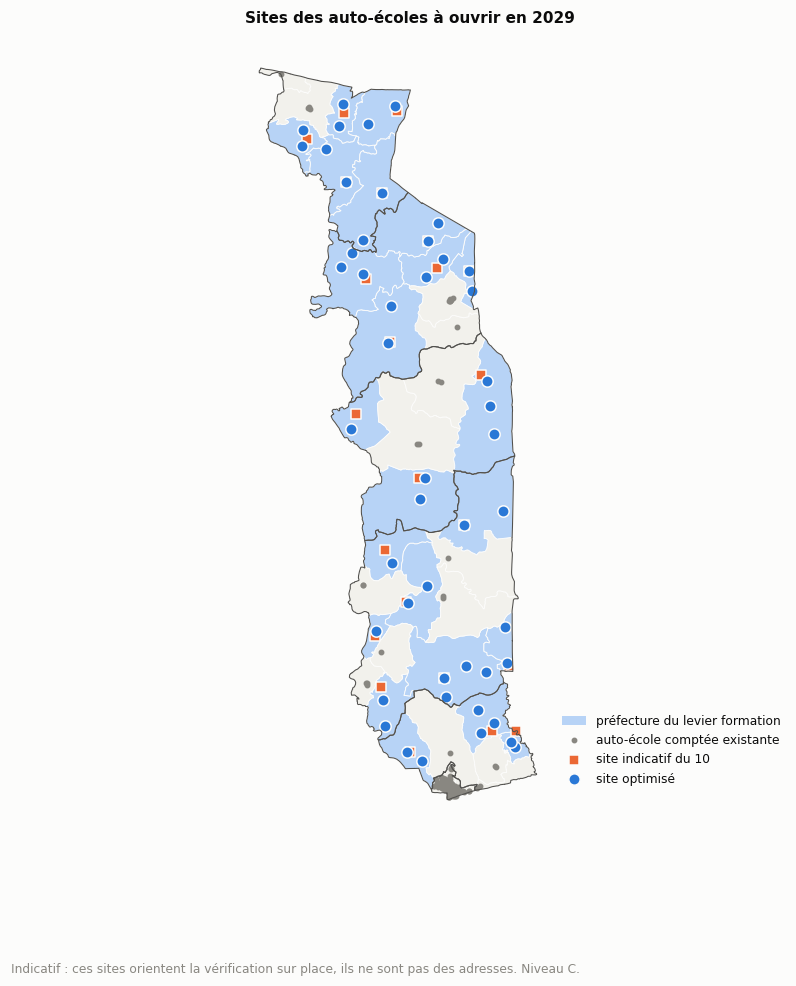

,23
Préfecture,Ensemble des 23
Zone,NaN
Recommandation,REC-F1 ; REC-F2
Auto-écoles à ouvrir (2029),48
Sites distincts retenus,48
Lieux candidats,257
Population (2022),2932492
"Couverte à 10 km, avant (%)",2.4
"Couverte, site indicatif du 10 (%)",32.2
"Couverte, sites optimisés (%)",56.7


In [6]:
e = emp[emp["Préfecture"] != "Ensemble des 23"].set_index("Préfecture").sort_values("Couverte, sites optimisés (%)")
fig, ax = plt.subplots(figsize=(9, 8.5))
y = np.arange(len(e))
ax.hlines(y, e["Couverte, site indicatif du 10 (%)"], e["Couverte, sites optimisés (%)"], color=AXE, linewidth=2)
ax.scatter(e["Couverte à 10 km, avant (%)"], y, color=MUET, s=30, label="avant (auto-écoles comptées existantes)", zorder=3)
ax.scatter(e["Couverte, site indicatif du 10 (%)"], y, color=SERIES[1], s=55, marker="s", label="tout au site indicatif du 10", zorder=3)
ax.scatter(e["Couverte, sites optimisés (%)"], y, color=SERIES[0], s=65, label="sites optimisés", zorder=3)
ax.set_yticks(y, [f"{p} ({int(k)})" for p, k in zip(e.index, e["Auto-écoles à ouvrir (2029)"])])
ax.set_xlim(0, 100); ax.set_xlabel("part de la population de la préfecture à moins de 10 km d’une auto-école (%)")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Population couverte à 10 km, par préfecture (entre parenthèses : auto-écoles à ouvrir en 2029)")
pied(fig, "Grille WorldPop 2020 ramenée au recensement 2022 ; lieux candidats HDX (D13) ; choix glouton (A1-10). Niveau C.")
plt.show()

ae_pts = gpd.read_file(TRAITE / "geo" / "auto_ecoles.geojson").to_crs(UTM31N)
ae_pts = ae_pts[ae_pts["Comptée (R-12)"] == True]
dep = pd.read_csv(TRAITE / "D13_points_depart_o4_08.csv")
dep = dep[dep["Préfecture"].isin(e.index)]
fig, ax = plt.subplots(figsize=(7, 9.5))
geo.plot(ax=ax, color=geo["Préfecture"].isin(e.index).map({True: SEQUENTIEL[0], False: "#f2f1ec"}), edgecolor=SURFACE, linewidth=0.6)
ax.scatter(ae_pts.geometry.x, ae_pts.geometry.y, s=8, color=MUET, label="auto-école comptée existante")
ax.scatter(dep["x_utm"], dep["y_utm"], s=40, marker="s", color=SERIES[1], edgecolor=SURFACE, label="site indicatif du 10")
ax.scatter(sites["x_utm"], sites["y_utm"], s=55, color=SERIES[0], edgecolor=SURFACE, label="site optimisé")
fond(ax, "Sites des auto-écoles à ouvrir en 2029")
ax.legend(handles=[Patch(facecolor=SEQUENTIEL[0], label="préfecture du levier formation"), *ax.get_legend_handles_labels()[0]],
          fontsize=8, loc="lower left", bbox_to_anchor=(1.0, 0.05))
pied(fig, "Indicatif : ces sites orientent la vérification sur place, ils ne sont pas des adresses. Niveau C.")
plt.show()
display(emp[emp["Préfecture"] == "Ensemble des 23"].T)

## 6. Au national : permis moto et sécurité routière

Permis A : la quantité qui garde le taux de 2022–2024 pour 1 000 habitants de 18 ans et plus. Sécurité : deux références sans action nouvelle (taux inchangé ; tendance 2010–2024), la cible de la Décennie d’action de l’ONU (moitié des blessés et des tués de 2021 en 2030) et, pour les tués, le plafond du casque. Aucun effet des routes ou des auto-écoles sur les accidents n’est modélisé (A1-8).

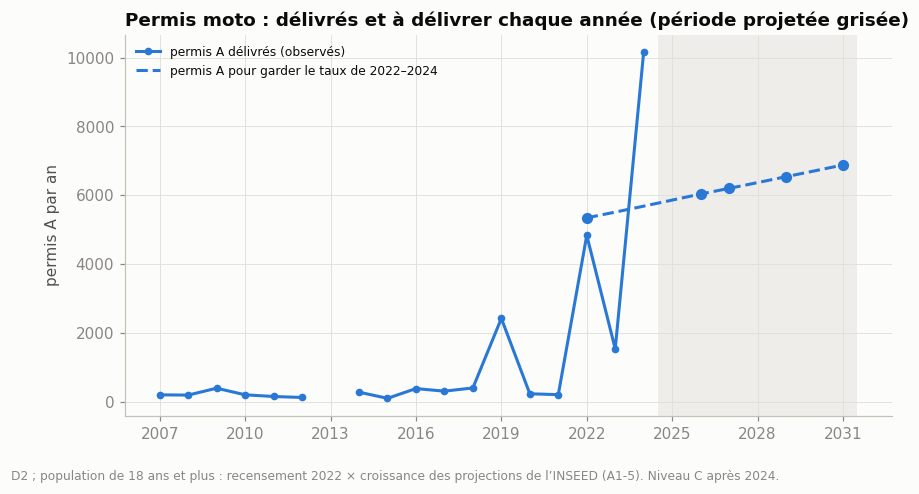

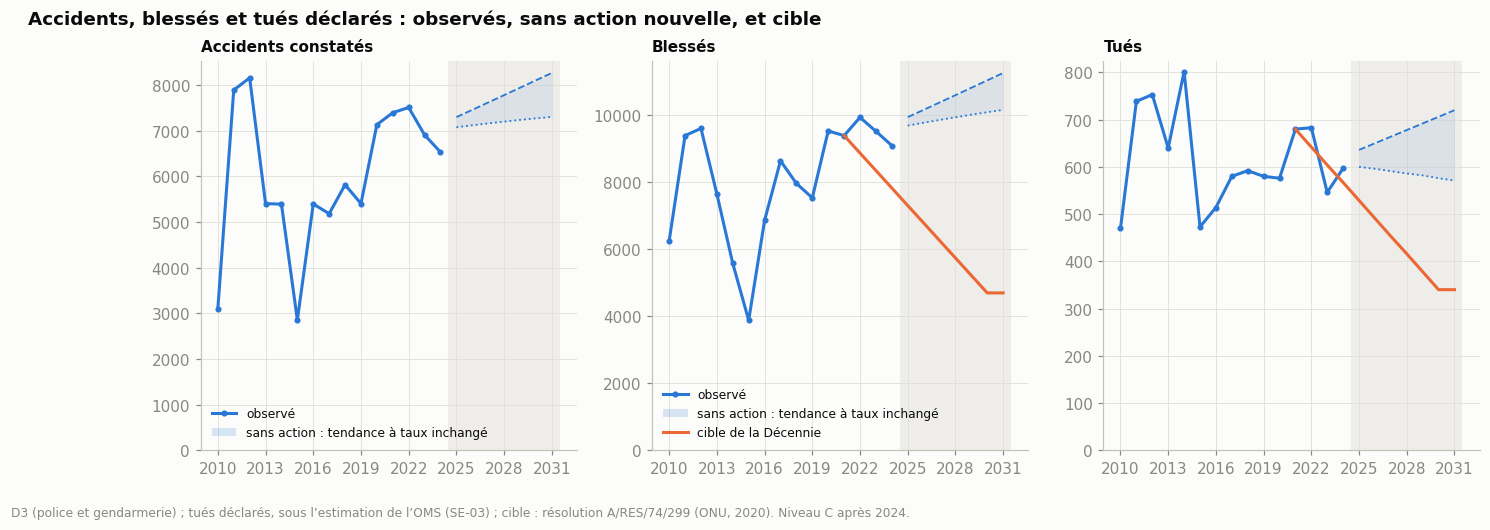

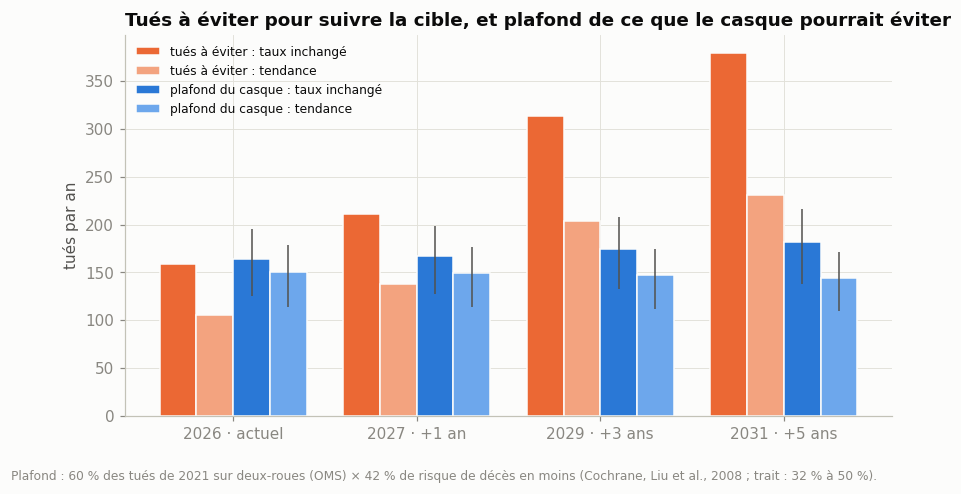

Année,2026,2027,2029,2031
Série,,,,
Cible de la Décennie,491.0,453.0,378.0,340.0
Plafond du casque (taux inchangé),164.0,167.0,174.0,182.0
Plafond du casque (tendance),150.0,149.0,147.0,144.0
Taux inchangé,650.0,664.0,692.0,720.0
Tendance,596.0,591.0,582.0,571.0
Écart à la cible (taux inchangé),159.0,211.0,314.0,380.0
Écart à la cible (tendance),105.0,138.0,204.0,231.0


In [7]:
def serie(mesure, s):
    return nat[(nat["Mesure"] == mesure) & (nat["Série"] == s)].set_index("Année")

fig, ax = plt.subplots(figsize=(9, 4.5))
o, b = serie("Permis A", "observé"), serie("Permis A", "Permis A pour garder le taux")
ax.plot(o.index, o["Valeur"], color=SERIES[0], marker="o", markersize=4, label="permis A délivrés (observés)")
ax.plot(b.index, b["Valeur"], color=SERIES[0], linestyle="--", label="permis A pour garder le taux de 2022–2024")
ax.scatter(list(PALIERS), b.loc[list(PALIERS), "Valeur"], color=SERIES[0], s=40, zorder=3)
ax.axvspan(2024.5, 2031.5, color=GRILLE, alpha=0.5, linewidth=0)
axe_annees(ax); ax.set_ylabel("permis A par an"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("Permis moto : délivrés et à délivrer chaque année (période projetée grisée)")
pied(fig, "D2 ; population de 18 ans et plus : recensement 2022 × croissance des projections de l’INSEED (A1-5). Niveau C après 2024.")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, mesure in zip(axes, ("Accidents constatés", "Blessés", "Tués")):
    o, ti, td = serie(mesure, "observé"), serie(mesure, "Taux inchangé"), serie(mesure, "Tendance")
    ax.plot(o.index, o["Valeur"], color=SERIES[0], marker="o", markersize=3, label="observé")
    ax.fill_between(ti.index, td["Valeur"], ti["Valeur"], color=SERIES[0], alpha=0.18, linewidth=0, label="sans action : tendance à taux inchangé")
    ax.plot(ti.index, ti["Valeur"], color=SERIES[0], linestyle="--", linewidth=1.2)
    ax.plot(td.index, td["Valeur"], color=SERIES[0], linestyle=":", linewidth=1.2)
    if mesure != "Accidents constatés":
        c = serie(mesure, "Cible de la Décennie")
        ax.plot(c.index, c["Valeur"], color=SERIES[1], linewidth=2, label="cible de la Décennie")
    ax.axvspan(2024.5, 2031.5, color=GRILLE, alpha=0.5, linewidth=0)
    axe_annees(ax); ax.set_ylim(bottom=0); ax.set_title(mesure, fontsize=10)
axes[0].legend(fontsize=8, loc="lower left"); axes[1].legend(fontsize=8, loc="lower left")
fig.suptitle("Accidents, blessés et tués déclarés : observés, sans action nouvelle, et cible", x=0.02, ha="left", fontweight="bold")
pied(fig, "D3 (police et gendarmerie) ; tués déclarés, sous l’estimation de l’OMS (SE-03) ; cible : résolution A/RES/74/299 (ONU, 2020). Niveau C après 2024.")
plt.show()

an = [a for a in PALIERS if a >= 2026]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(an))
largeur = 0.2
for k, (s, couleur, lib) in enumerate((("Écart à la cible (taux inchangé)", SERIES[1], "tués à éviter : taux inchangé"),
                                         ("Écart à la cible (tendance)", "#f3a37f", "tués à éviter : tendance"),
                                         ("Plafond du casque (taux inchangé)", SERIES[0], "plafond du casque : taux inchangé"),
                                         ("Plafond du casque (tendance)", SEQUENTIEL[1], "plafond du casque : tendance"))):
    d = serie("Tués", s).loc[an]
    ax.bar(x + (k - 1.5) * largeur, d["Valeur"], width=largeur, color=couleur, label=lib, edgecolor=SURFACE)
    if s.startswith("Plafond"):
        ax.errorbar(x + (k - 1.5) * largeur, d["Valeur"], yerr=[d["Valeur"] - d["Borne basse"], d["Borne haute"] - d["Valeur"]],
                    fmt="none", ecolor=ENCRE_2, elinewidth=1)
ax.set_xticks(x, [PALIERS[a] for a in an]); ax.set_ylabel("tués par an"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("Tués à éviter pour suivre la cible, et plafond de ce que le casque pourrait éviter")
pied(fig, "Plafond : 60 % des tués de 2021 sur deux-roues (OMS) × 42 % de risque de décès en moins (Cochrane, Liu et al., 2008 ; trait : 32 % à 50 %).")
plt.show()
display(nat[(nat["Mesure"] == "Tués") & nat["Année"].isin(an)].pivot(index="Série", columns="Année", values="Valeur"))